In [9]:
"""
Prompt:

I'm working on the "Smart meters in London" Dataset and these are my requirements
Choose any block file from hhblock folder
choose any consumer LCLid to work with
get his Acorn data and use it with the ID
Plot line, seasonal and heatmap plots with insights
Apply Decompsotion Techinques discussed like
Detrending:
Moving Average
LOESS
Deseasonalization:
Period adjusted average
Fourier Series
break down the steps i could follow
"""

'\nPrompt:\n\nI\'m working on the "Smart meters in London" Dataset and these are my requirements\nChoose any block file from hhblock folder\nchoose any consumer LCLid to work with\nget his Acorn data and use it with the ID\nPlot line, seasonal and heatmap plots with insights\nApply Decompsotion Techinques discussed like\nDetrending:\nMoving Average\nLOESS\nDeseasonalization:\nPeriod adjusted average\nFourier Series\nbreak down the steps i could follow\n'

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from calendar import month_name

In [11]:
block = pd.read_csv('block_21.csv')
info = pd.read_csv('informations_households.csv')

In [12]:
acorn = pd.read_excel('acorn_details.xlsx')

In [13]:
print(block.head())
print(info.head())
print(acorn.head())

       LCLid         day   hh_0   hh_1   hh_2   hh_3   hh_4   hh_5  hh_6  \
0  MAC000138  2011-12-16  0.952  1.120  0.774  0.012  0.187  0.026   0.0   
1  MAC000138  2011-12-17  0.286  0.601  0.108  0.032  0.002  0.000   0.0   
2  MAC000138  2011-12-18  0.115  0.131  0.034  0.000  0.000  0.000   0.0   
3  MAC000138  2011-12-19  0.391  0.011  0.120  0.023  0.000  0.000   0.0   
4  MAC000138  2011-12-20  0.202  0.041  0.037  0.002  0.034  0.000   0.0   

    hh_7  ...  hh_38  hh_39  hh_40  hh_41  hh_42  hh_43  hh_44  hh_45  hh_46  \
0  0.000  ...  0.309  0.175  0.095  0.078  1.504  0.258  0.119  1.181  0.848   
1  0.000  ...  0.074  0.077  0.068  0.131  0.057  0.067  0.069  0.096  0.159   
2  0.012  ...  0.065  0.090  0.051  0.124  0.048  0.063  0.074  0.071  0.056   
3  0.000  ...  1.044  0.386  1.020  0.654  0.841  0.710  0.055  0.056  0.659   
4  0.000  ...  0.019  0.026  0.057  0.017  0.019  0.369  0.496  0.210  0.095   

   hh_47  
0  0.325  
1  1.193  
2  0.227  
3  0.014  
4  0.01

In [14]:
print("Unique LCLid count:", block['LCLid'].nunique())
print("Some sample LCLids:", block['LCLid'].unique()[:10])
print(block['LCLid'].value_counts().head(25))

Unique LCLid count: 50
Some sample LCLids: ['MAC000138' 'MAC000144' 'MAC000150' 'MAC000203' 'MAC000205' 'MAC000214'
 'MAC000218' 'MAC000220' 'MAC000398' 'MAC003460']
LCLid
MAC000150    821
MAC000205    819
MAC000214    818
MAC000218    816
MAC000220    814
MAC000203    811
MAC000138    803
MAC004534    797
MAC004535    796
MAC004531    795
MAC004522    795
MAC004528    790
MAC004537    788
MAC004373    713
MAC004380    711
MAC004388    711
MAC004383    710
MAC004390    710
MAC004428    710
MAC004410    709
MAC004377    709
MAC004379    709
MAC004446    708
MAC004421    708
MAC004411    708
Name: count, dtype: int64


In [15]:
chosen_id = 'MAC000150'
chosen_id

'MAC000150'

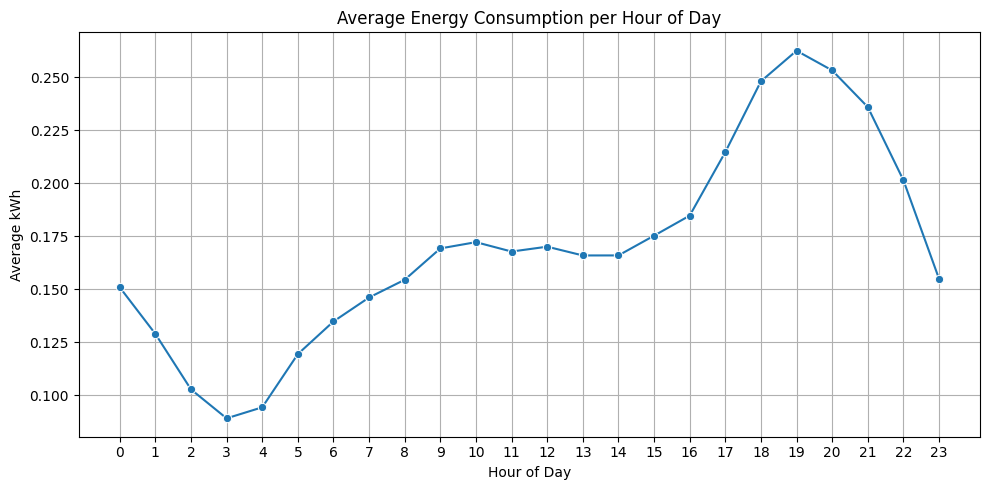

In [16]:
# Melt the dataframe into long format
half_hour_columns = [f"hh_{i}" for i in range(48)]
df_long = block.melt(id_vars=["LCLid", "day"], value_vars=half_hour_columns,
                  var_name="half_hour", value_name="energy_kwh")

# Convert 'day' to datetime and extract half-hour index
df_long['day'] = pd.to_datetime(df_long['day'])
df_long['half_hour'] = df_long['half_hour'].str.extract('(\d+)').astype(int)

# Compute actual datetime for each reading
df_long['timestamp'] = df_long['day'] + pd.to_timedelta(df_long['half_hour'] * 30, unit='min')

# Add hour and 4-hour group for grouping
df_long['hour'] = df_long['timestamp'].dt.hour
df_long['4_hour_block'] = (df_long['hour'] // 4) * 4

# Aggregate energy usage
hourly_avg = df_long.groupby('hour')['energy_kwh'].mean()
block_avg = df_long.groupby('4_hour_block')['energy_kwh'].mean()

# Plot hourly average energy usage
plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o')
plt.title('Average Energy Consumption per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average kWh')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


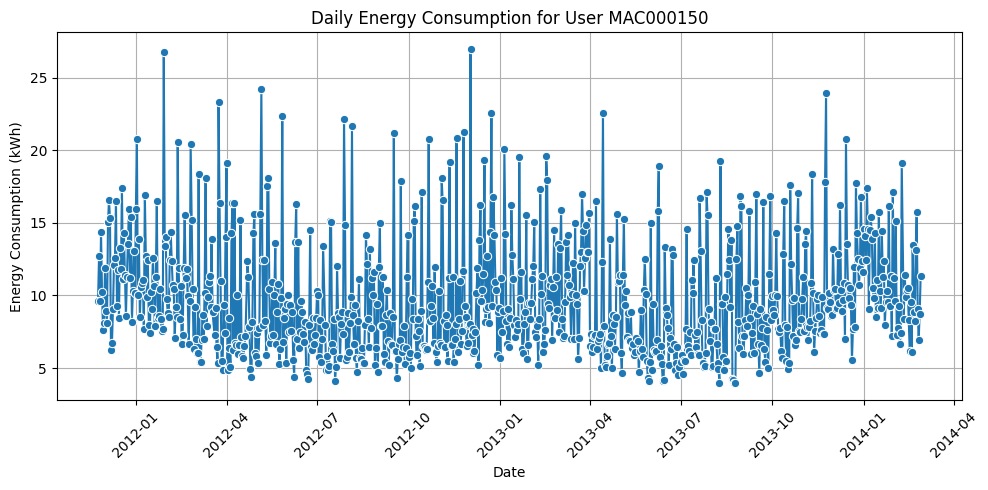

In [17]:
df_user = df_long[df_long['LCLid'] == chosen_id].copy()

df_user['date'] = df_user['timestamp'].dt.date
daily_user_energy = df_user.groupby('date')['energy_kwh'].sum().reset_index()

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_user_energy, x='date', y='energy_kwh', marker='o')
plt.title(f'Daily Energy Consumption for User {chosen_id}')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/0f/3f4mpz3513d528tcrnjsyv_w0000gn/T/ipykernel_1419/2493393692.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for weekday, group in df_long.groupby('weekday_name'):


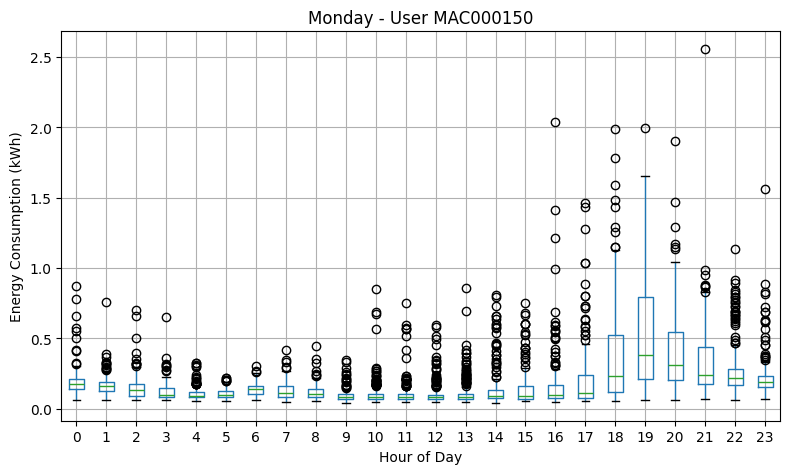

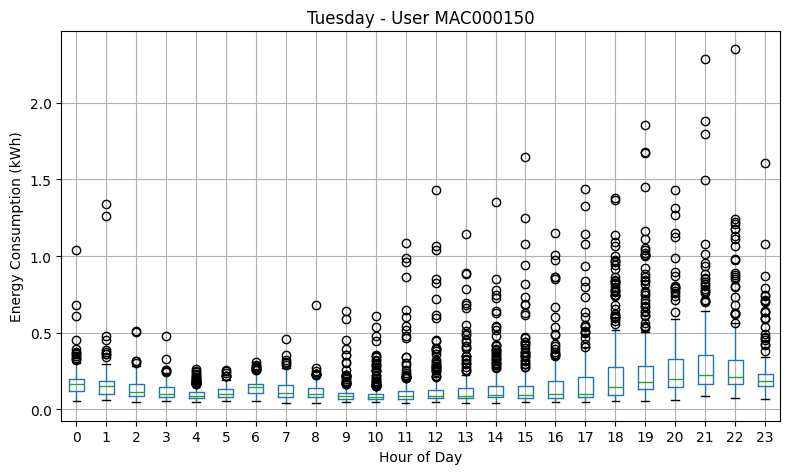

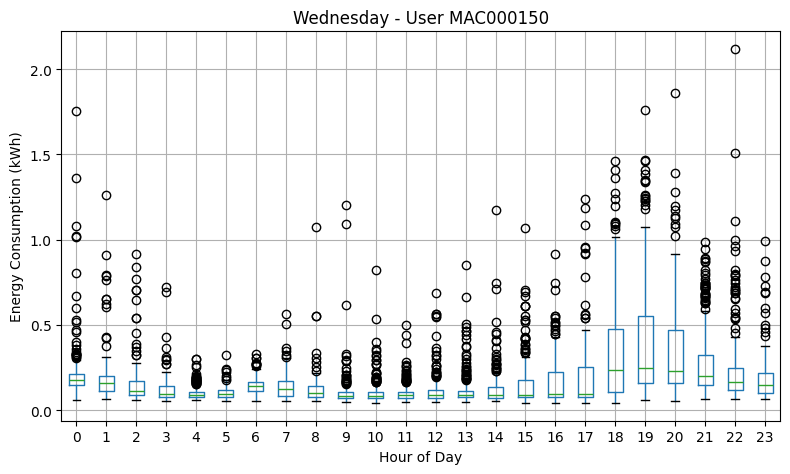

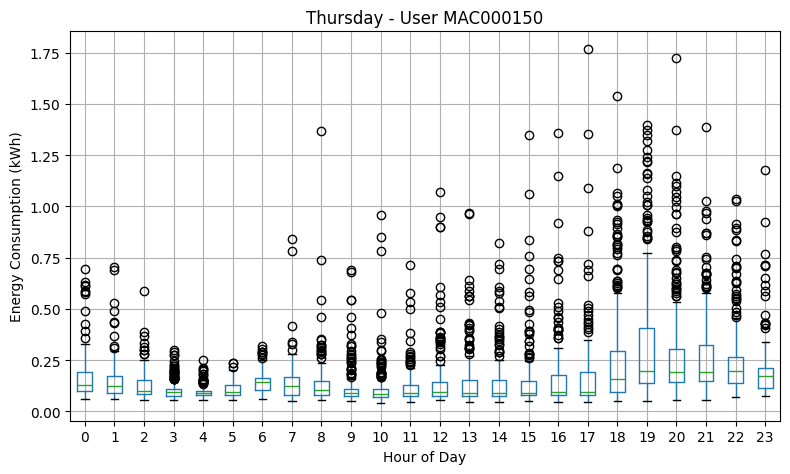

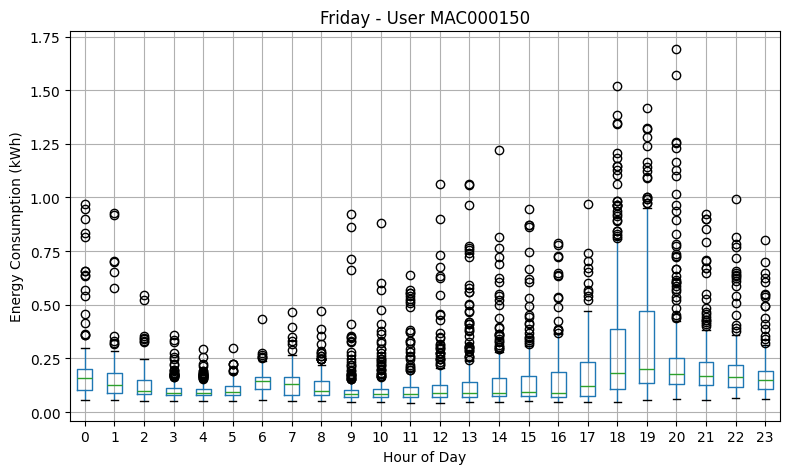

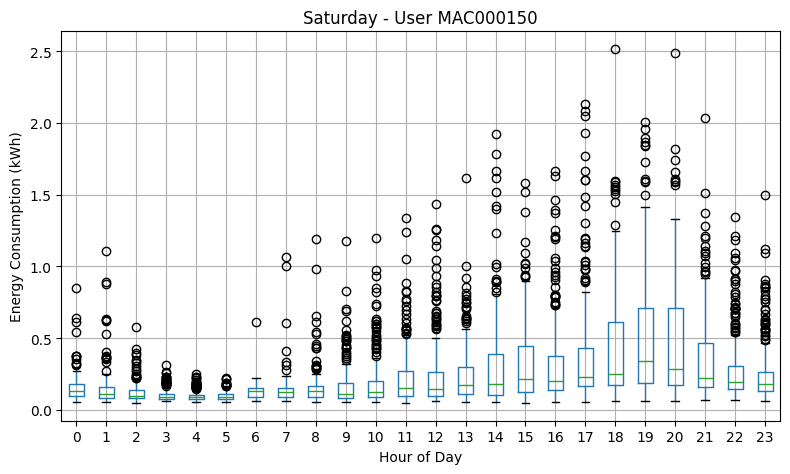

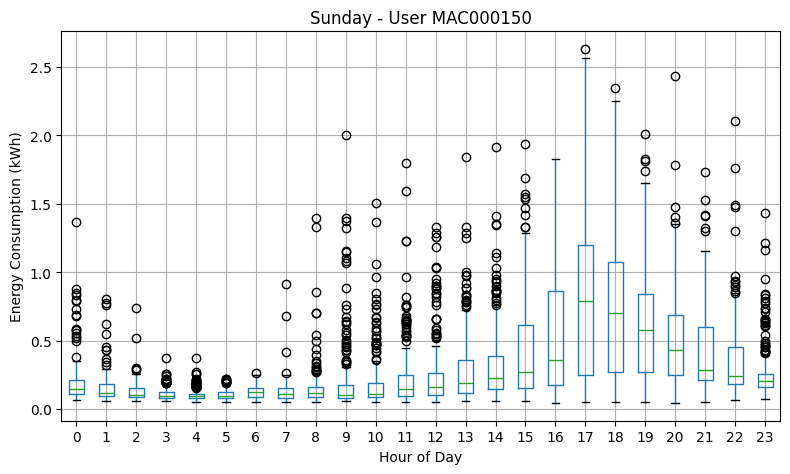

In [18]:
# Filter for one user
df_user = block[block['LCLid'] == chosen_id].copy()

# Melt user data
df_long = df_user.melt(
    id_vars=["LCLid", "day"],
    value_vars=half_hour_columns,
    var_name="half_hour",
    value_name="energy_kwh"
)

# Parse timestamps
df_long['day'] = pd.to_datetime(df_long['day'])
df_long['half_hour'] = df_long['half_hour'].str.extract('(\d+)').astype(int)
df_long['timestamp'] = df_long['day'] + pd.to_timedelta(df_long['half_hour'] * 30, unit='min')

# Drop missing values
df_long = df_long.dropna(subset=['energy_kwh'])

# Add hour and weekday name
df_long['hour'] = df_long['timestamp'].dt.hour
df_long['weekday_name'] = df_long['timestamp'].dt.day_name()

# Optional: Sort days (optional but helps with order)
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_long['weekday_name'] = pd.Categorical(df_long['weekday_name'], categories=ordered_days, ordered=True)

# Plot boxplots per weekday
for weekday, group in df_long.groupby('weekday_name'):
    fig, ax = plt.subplots(figsize=(8, 5))
    group.boxplot(column='energy_kwh', by='hour', ax=ax)
    ax.set_title(f'{weekday} - User {chosen_id}')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Energy Consumption (kWh)')
    ax.grid(True)
    plt.suptitle('')  # Remove default suptitle
    plt.tight_layout()
    plt.show()


                     energy_consumption month_name
timestamp                                         
2011-11-24 00:00:00              0.1810   November
2011-11-24 01:00:00              0.1535   November
2011-11-24 02:00:00              0.1500   November
2011-11-24 03:00:00              0.1155   November
2011-11-24 04:00:00              0.0755   November


/var/folders/0f/3f4mpz3513d528tcrnjsyv_w0000gn/T/ipykernel_1419/1415007187.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts_df = df_long['energy_kwh'].resample('H').mean().to_frame(name='energy_consumption')


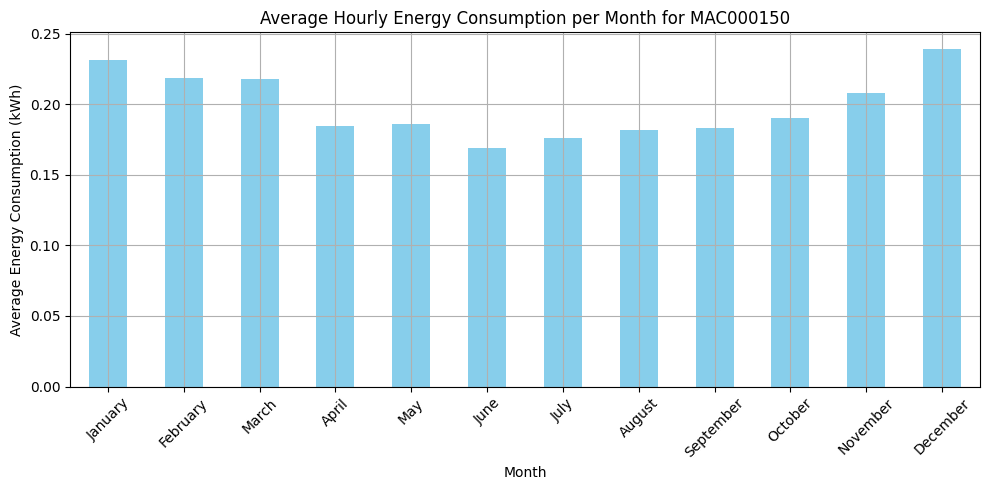

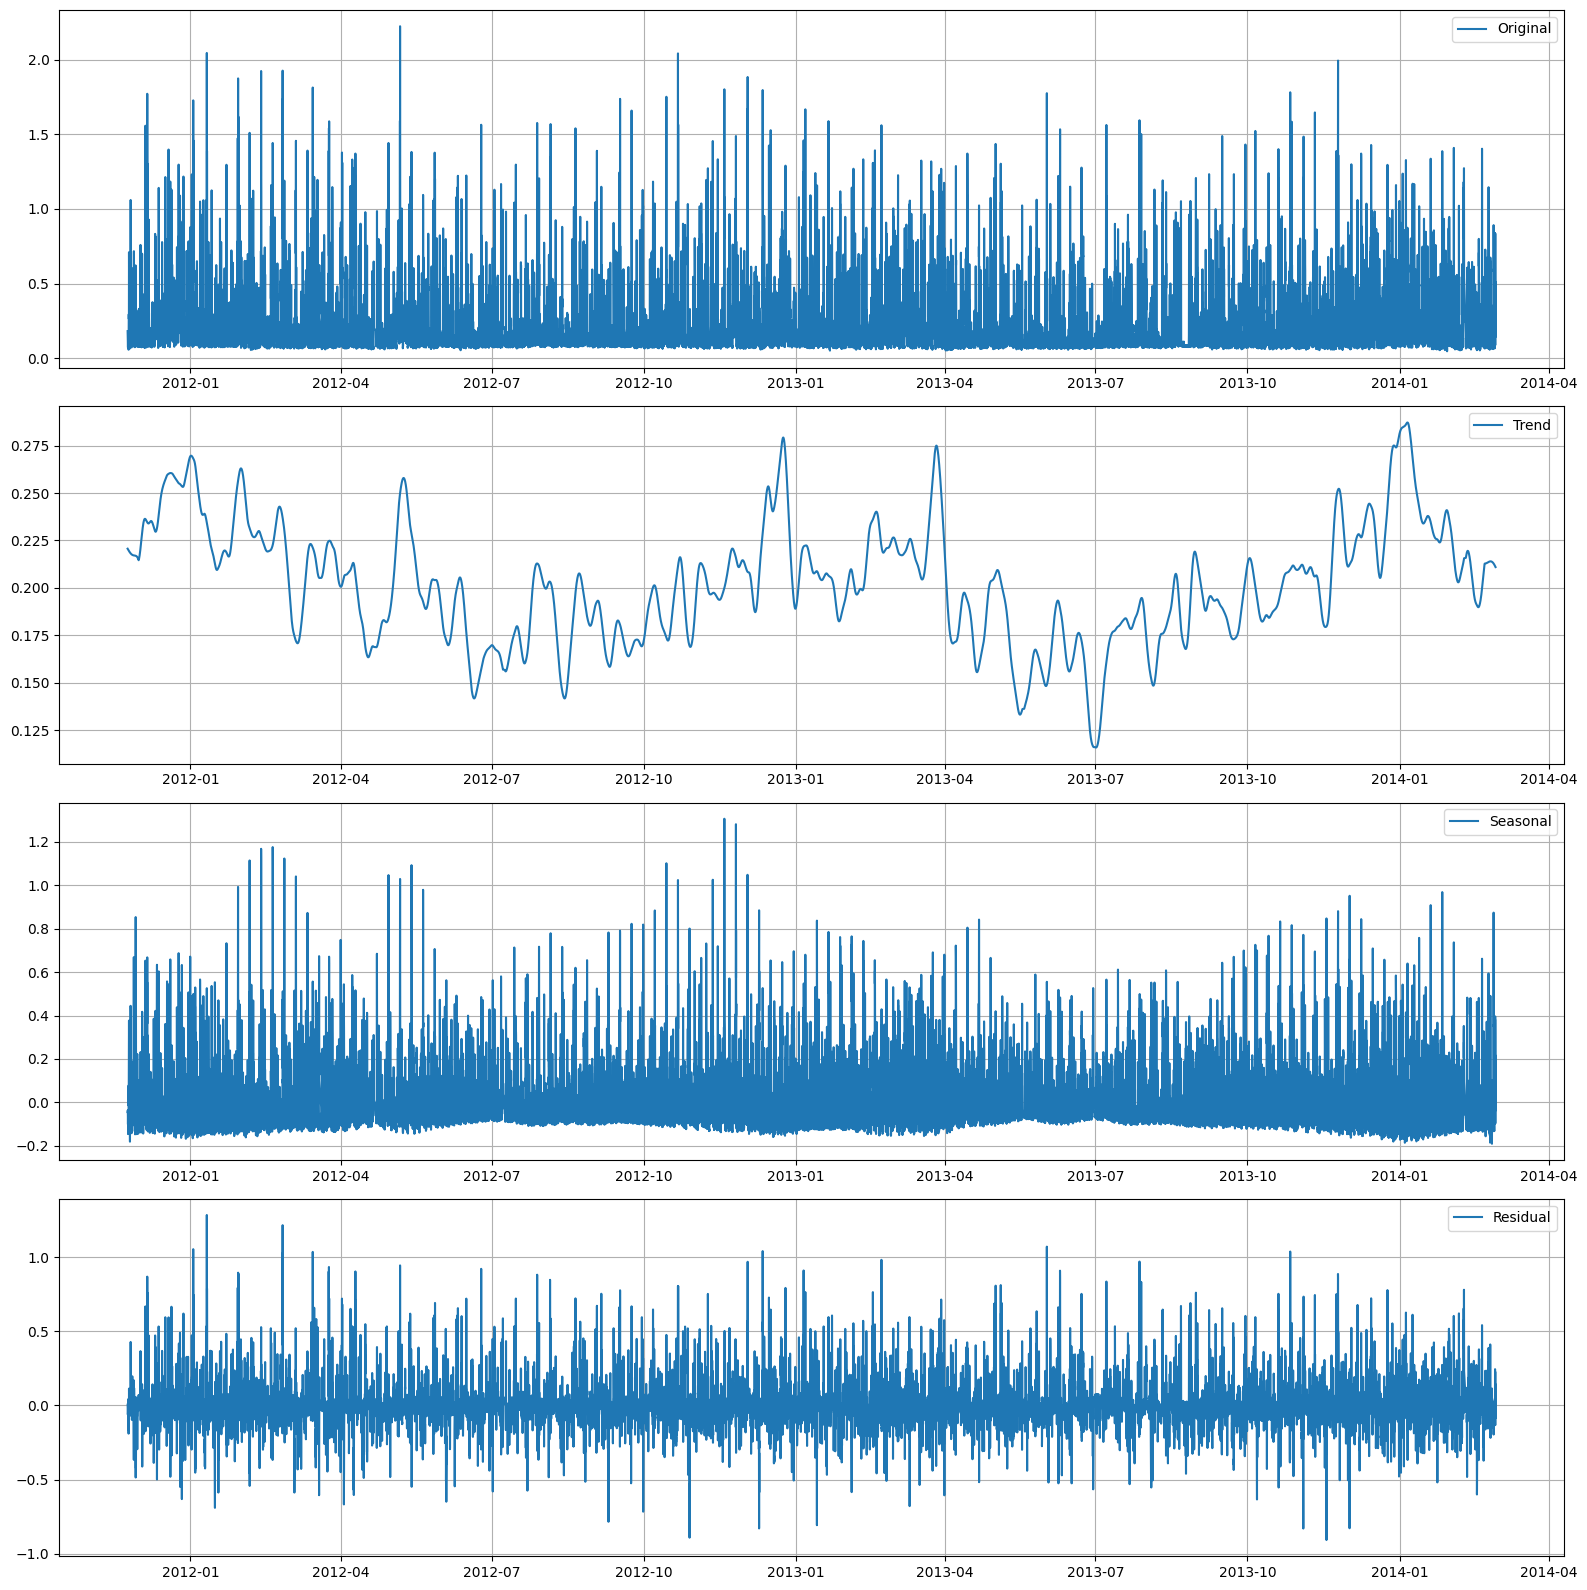

In [27]:
# Step 1: Filter data for the chosen user
df_user = block[block['LCLid'] == chosen_id].copy()

# Step 2: Melt and build timestamp
df_long = df_user.melt(
    id_vars=["LCLid", "day"],
    value_vars=half_hour_columns,
    var_name="half_hour",
    value_name="energy_kwh"
)

df_long['day'] = pd.to_datetime(df_long['day'])
df_long['half_hour'] = df_long['half_hour'].str.extract('(\d+)').astype(int)
df_long['timestamp'] = df_long['day'] + pd.to_timedelta(df_long['half_hour'] * 30, unit='min')

# Drop missing and set timestamp
df_long = df_long.dropna(subset=['energy_kwh'])
df_long.set_index('timestamp', inplace=True)

# Step 3: Resample to hourly average
ts_df = df_long['energy_kwh'].resample('H').mean().to_frame(name='energy_consumption')
ts_df = ts_df.dropna()

# Step 4: Add month name column
ts_df['month_name'] = ts_df.index.month_name()
print(ts_df.head())
# Step 5: Plot monthly averages
monthly_avg = ts_df.groupby('month_name')['energy_consumption'].mean()

# Reorder months to calendar order
from calendar import month_name
ordered_months = list(month_name)[1:]
monthly_avg = monthly_avg.reindex(ordered_months)

# Plot average energy consumption per month
plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='skyblue')
plt.title(f'Average Hourly Energy Consumption per Month for {chosen_id}')
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption (kWh)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 6: STL decomposition function
def plot_stl_decomposition(ts_df, column, period=7*24):  # Weekly seasonality
    stl = STL(ts_df[column], period=period)
    res = stl.fit()
    fig, axs = plt.subplots(4, 1, figsize=(16, 16))
    axs[0].plot(ts_df[column], label='Original')
    axs[1].plot(res.trend, label='Trend')
    axs[2].plot(res.seasonal, label='Seasonal')
    axs[3].plot(res.resid, label='Residual')
    for ax in axs:
        ax.legend()
        ax.grid()
    fig.tight_layout()
    plt.show()

# Step 7: Apply STL
plot_stl_decomposition(ts_df, 'energy_consumption')


In [20]:
# top graph show that the user uses more energy in the winter monthes
# and less in the summer monthes
# probably to heating overhead of usage in the winter months

# the orginal raw data is shown in the first graph
# the trend is shown in the second graph
# the seasonal is shown in the third graph
# the residual is shown in the fourth graph

# orginal data is hard to interpret
# trend is the long term movement in the data
# seasonal is the repeating pattern in the data and shows
# a clear weekly pattern
# residual is the random noise in the data, usage spikes or anomalies

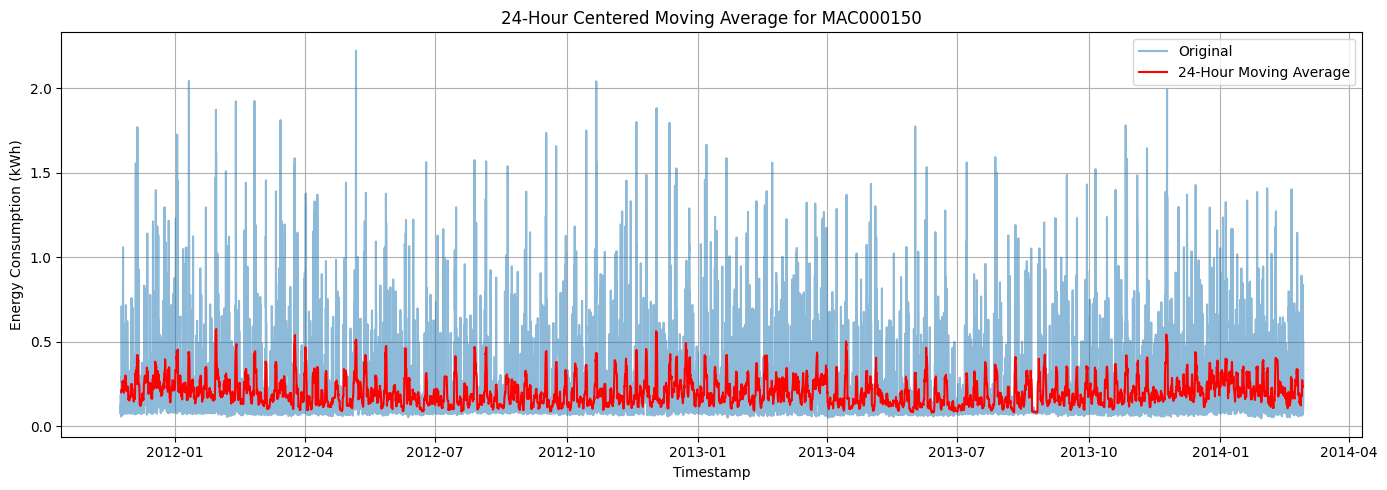

In [21]:
# Define moving average window (e.g., 24 for daily average over hourly data)
window_size = 24  # 24 hours = 1 day

# Compute centered moving average
ts_df['moving_avg'] = ts_df['energy_consumption'].rolling(window=window_size, center=True).mean()

# Plot original vs. moving average
plt.figure(figsize=(14, 5))
plt.plot(ts_df['energy_consumption'], label='Original', alpha=0.5)
plt.plot(ts_df['moving_avg'], label=f'{window_size}-Hour Moving Average', color='red')
plt.title(f'{window_size}-Hour Centered Moving Average for {chosen_id}')
plt.xlabel('Timestamp')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


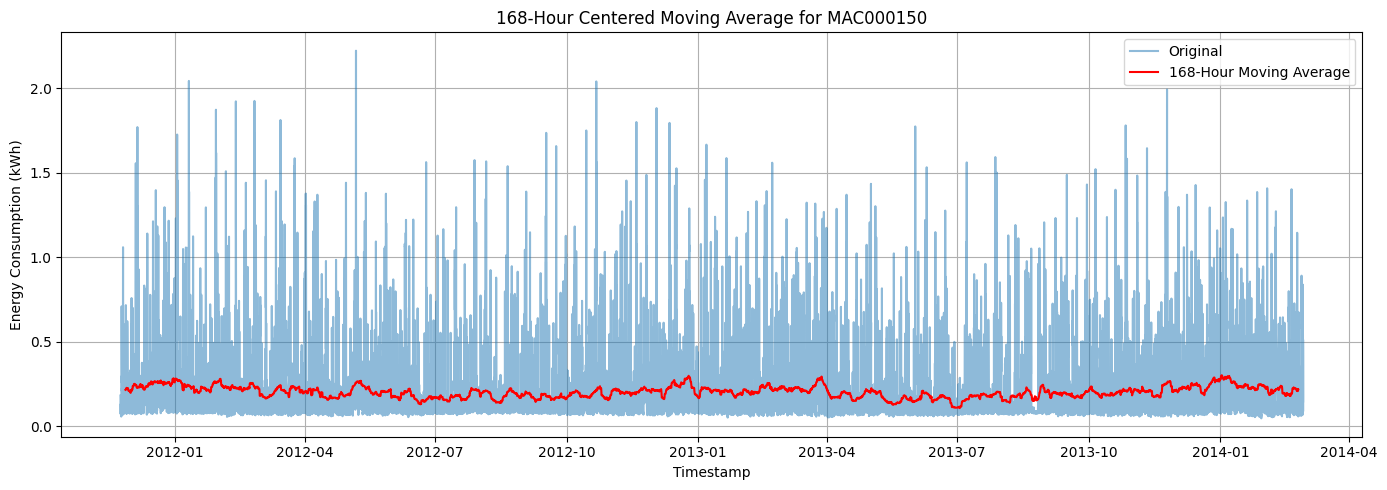

In [22]:
# Define moving average window (e.g., 24 for daily average over hourly data)
window_size = 24 *7 # 24 hours = 1 day * 7days = weekly

# Compute centered moving average
ts_df['moving_avg'] = ts_df['energy_consumption'].rolling(window=window_size, center=True).mean()

# Plot original vs. moving average
plt.figure(figsize=(14, 5))
plt.plot(ts_df['energy_consumption'], label='Original', alpha=0.5)
plt.plot(ts_df['moving_avg'], label=f'{window_size}-Hour Moving Average', color='red')
plt.title(f'{window_size}-Hour Centered Moving Average for {chosen_id}')
plt.xlabel('Timestamp')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


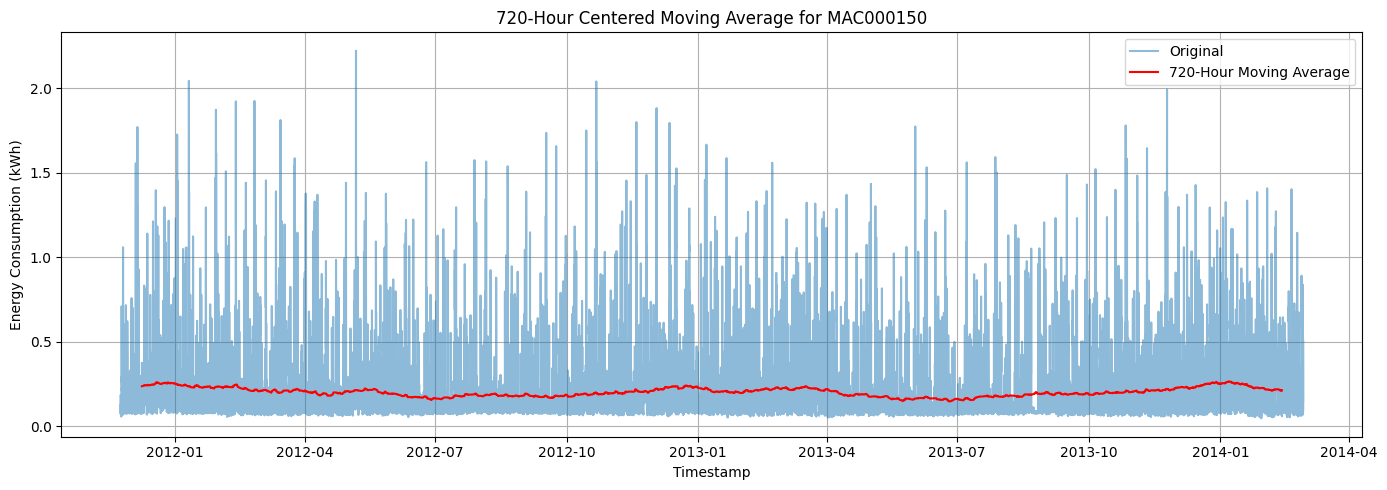

In [23]:

window_size = 24*30# 24 hours = 1 day * 30 days = Monthly

# Compute centered moving average
ts_df['moving_avg'] = ts_df['energy_consumption'].rolling(window=window_size, center=True).mean()

# Plot original vs. moving average
plt.figure(figsize=(14, 5))
plt.plot(ts_df['energy_consumption'], label='Original', alpha=0.5)
plt.plot(ts_df['moving_avg'], label=f'{window_size}-Hour Moving Average', color='red')
plt.title(f'{window_size}-Hour Centered Moving Average for {chosen_id}')
plt.xlabel('Timestamp')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


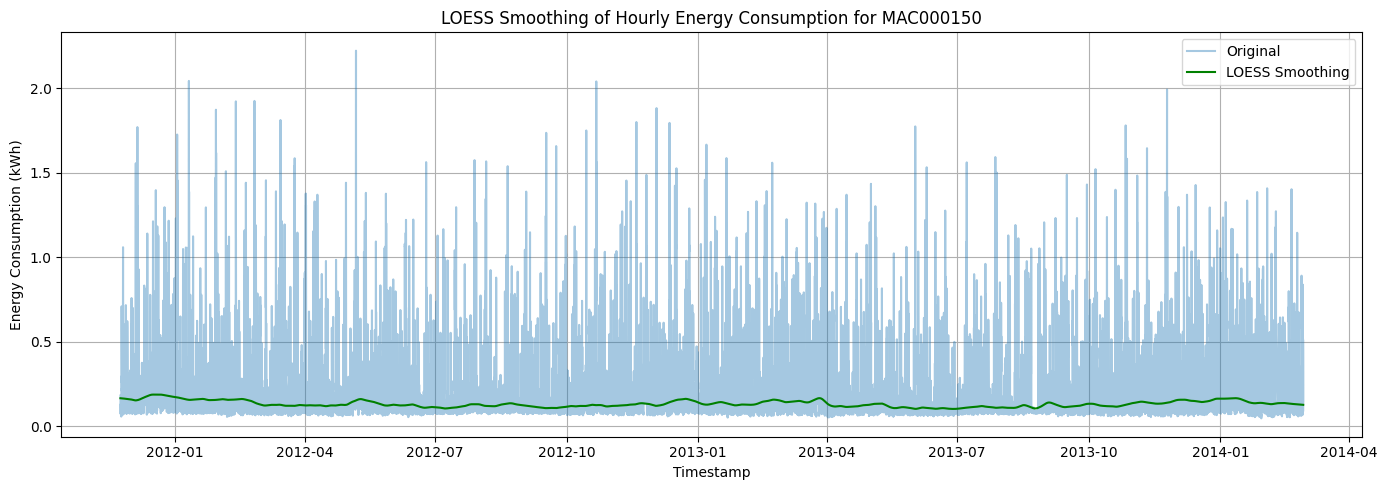

In [24]:
from statsmodels.nonparametric.smoothers_lowess import lowess

smoothed = lowess(
    ts_df['energy_consumption'], 
    ts_df.index, 
    frac=0.02, 
    return_sorted=False
)

ts_df['loess'] = smoothed

# Plot original vs LOESS
plt.figure(figsize=(14, 5))
plt.plot(ts_df['energy_consumption'], label='Original', alpha=0.4)
plt.plot(ts_df['loess'], label='LOESS Smoothing', color='green')
plt.title(f'LOESS Smoothing of Hourly Energy Consumption for {chosen_id}')
plt.xlabel('Timestamp')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/0f/3f4mpz3513d528tcrnjsyv_w0000gn/T/ipykernel_1419/4080990024.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_long.pivot_table(


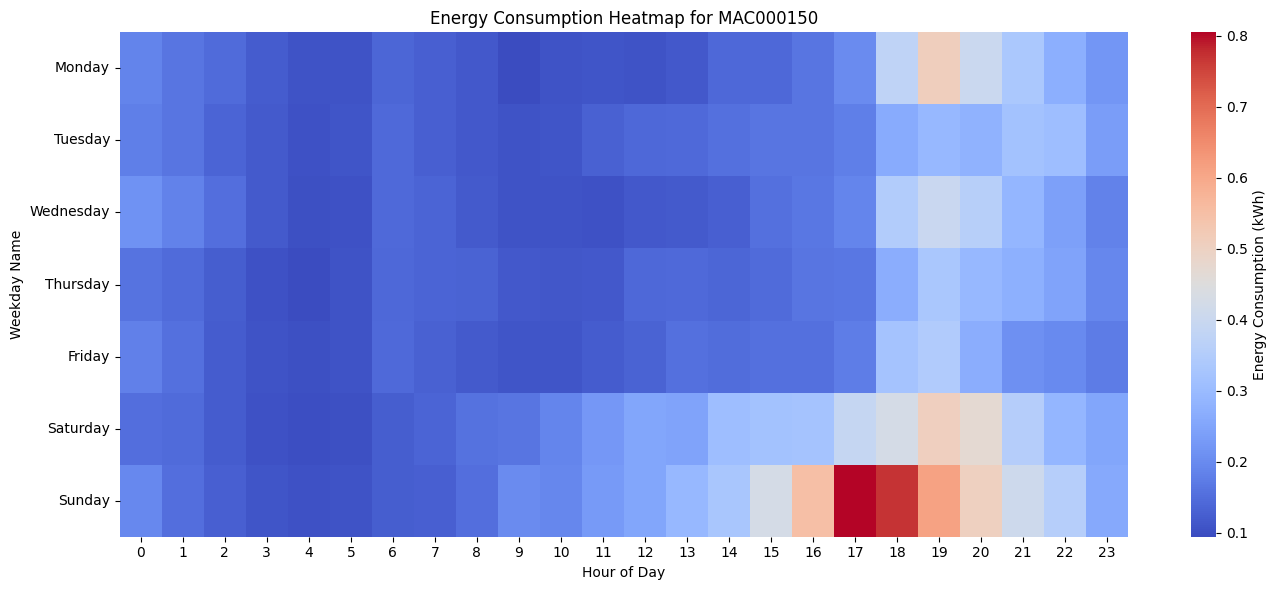

In [25]:
# Ensure data is filtered for the chosen user
df_user = block[block['LCLid'] == chosen_id].copy()

# Melt and prepare timestamp
df_long = df_user.melt(
    id_vars=["LCLid", "day"],
    value_vars=half_hour_columns,
    var_name="half_hour",
    value_name="energy_kwh"
)

df_long['day'] = pd.to_datetime(df_long['day'])
df_long['half_hour'] = df_long['half_hour'].str.extract('(\d+)').astype(int)
df_long['timestamp'] = df_long['day'] + pd.to_timedelta(df_long['half_hour'] * 30, unit='min')
df_long = df_long.dropna(subset=['energy_kwh'])

# Add weekday and hour
df_long['hour'] = df_long['timestamp'].dt.hour
df_long['weekday_name'] = df_long['timestamp'].dt.day_name()

# Optional: set weekday order
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_long['weekday_name'] = pd.Categorical(df_long['weekday_name'], categories=ordered_days, ordered=True)

# Create pivot table: average energy per weekday-hour
heatmap_data = df_long.pivot_table(
    index='weekday_name',
    columns='hour',
    values='energy_kwh',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', cbar_kws={'label': 'Energy Consumption (kWh)'})
plt.title(f'Energy Consumption Heatmap for {chosen_id}')
plt.xlabel('Hour of Day')
plt.ylabel('Weekday Name')
plt.tight_layout()
plt.show()


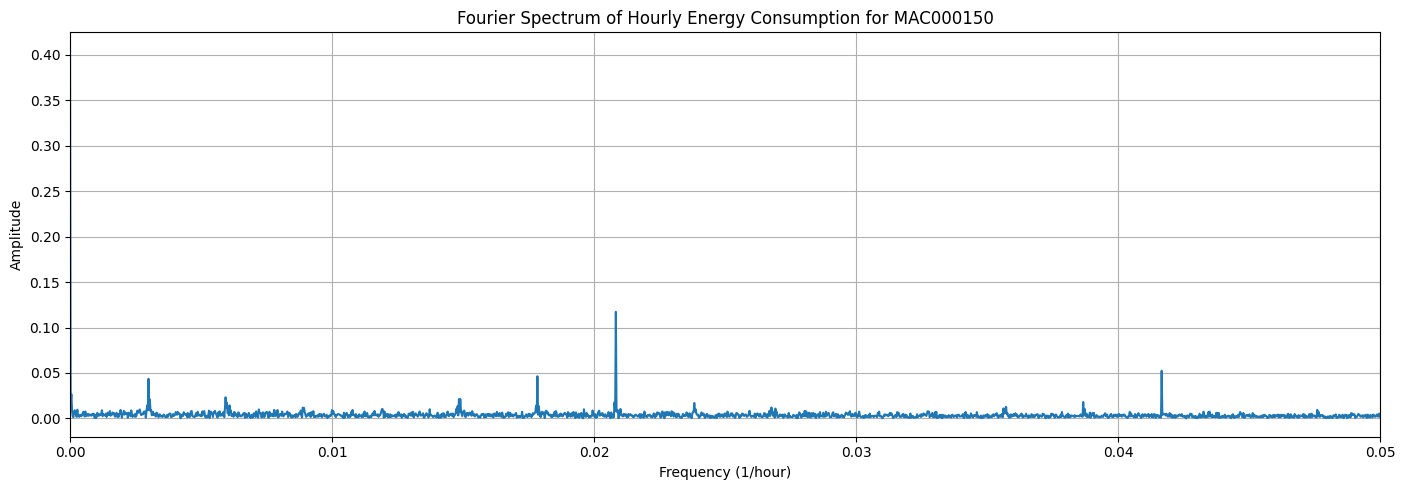

In [26]:
from scipy.fft import fft, fftfreq
import numpy as np
ts_clean = ts_df['energy_consumption'].dropna()


N = len(ts_clean)
# Sampling rate: 1 per hour
T = 2.0  


yf = fft(ts_clean)
xf = fftfreq(N, T)[:N // 2]  # Frequencies (positive side only)
amplitude = 2.0 / N * np.abs(yf[0:N // 2])  # Amplitude of each frequency

# Plot frequency vs amplitude
plt.figure(figsize=(14, 5))
plt.plot(xf, amplitude)
plt.title(f'Fourier Spectrum of Hourly Energy Consumption for {chosen_id}')
plt.xlabel('Frequency (1/hour)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 0.05)  
plt.show()
